# Imports

In [1]:
# %pip install kagglehub==0.3.13

In [2]:
# %pip show kagglehub kagglesdk
# %pip install grad-cam

In [3]:
import numpy as np
print(np.__version__)
print(np.__file__)
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import kagglehub
import nibabel as nib
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import ultralytics
from ultralytics import YOLO
from ultralytics.engine.results import Boxes
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

2.2.6
c:\Users\conno\anaconda3\envs\brats_final\lib\site-packages\numpy\__init__.py


c:\Users\conno\anaconda3\envs\brats_final\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# Download Dataset

In [4]:
path = kagglehub.dataset_download(
    "awsaf49/brats20-dataset-training-validation"
)

print("Dataset path:", path)

Dataset path: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1


In [5]:
# CHECK DATASET FOLDERS

os.listdir(path)

['BraTS2020_TrainingData', 'BraTS2020_ValidationData']

# Finding all MRI cases

In [6]:
base_path = os.path.join(
    path,
    "BraTS2020_TrainingData",
    "MICCAI_BraTS2020_TrainingData"
)

cases = []

for folder in os.listdir(base_path):

    full_path = os.path.join(base_path, folder)

    if os.path.isdir(full_path):
        cases.append(full_path)

print("Total cases:", len(cases))
print(cases[:3])

Total cases: 369
['C:\\Users\\conno\\.cache\\kagglehub\\datasets\\awsaf49\\brats20-dataset-training-validation\\versions\\1\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_001', 'C:\\Users\\conno\\.cache\\kagglehub\\datasets\\awsaf49\\brats20-dataset-training-validation\\versions\\1\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_002', 'C:\\Users\\conno\\.cache\\kagglehub\\datasets\\awsaf49\\brats20-dataset-training-validation\\versions\\1\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_003']


In [7]:
# Loads one MRI scan

sample_case = cases[0]

files = os.listdir(sample_case)
print(files)

['BraTS20_Training_001_flair.nii', 'BraTS20_Training_001_seg.nii', 'BraTS20_Training_001_t1.nii', 'BraTS20_Training_001_t1ce.nii', 'BraTS20_Training_001_t2.nii']


In [8]:
# Loading MRI and Mask

flair_path = None
mask_path = None

for file in files:

    if "flair" in file.lower():
        flair_path = os.path.join(sample_case, file)

    if "seg" in file.lower():
        mask_path = os.path.join(sample_case, file)

print("FLAIR:", flair_path)
print("MASK:", mask_path)

FLAIR: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001\BraTS20_Training_001_flair.nii
MASK: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001\BraTS20_Training_001_seg.nii


In [9]:
# getting structure of data

print(path)

for root, dirs, files in os.walk(path):
    print(root)
    print(files[:5])
    print("-" * 50)

    # stoppinh after a few folders
    if "BraTS20_Training_001" in root:
        break

C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1
[]
--------------------------------------------------
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData
[]
--------------------------------------------------
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData
['name_mapping.csv', 'survival_info.csv']
--------------------------------------------------
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001
['BraTS20_Training_001_flair.nii', 'BraTS20_Training_001_seg.nii', 'BraTS20_Training_001_t1.nii', 'BraTS20_Training_001_t1ce.nii', 'BraTS20_Training_001_t2.nii']
-------

In [10]:
# CELL 9 FIND MRI + MASK FILES

patient_folder = None

for folder in os.listdir(path):
    full_path = os.path.join(path, folder)

    if os.path.isdir(full_path):
        patient_folder = full_path
        break

print("Patient folder:", patient_folder)

files = os.listdir(patient_folder)

flair_path = None
mask_path = None

for file in files:

    if "flair" in file.lower():
        flair_path = os.path.join(patient_folder, file)

    if "seg" in file.lower():
        mask_path = os.path.join(patient_folder, file)

print("FLAIR:", flair_path)
print("MASK:", mask_path)

Patient folder: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData
FLAIR: None
MASK: None


In [11]:
base_path = os.path.join(path, "BraTS2020_TrainingData")
print(base_path)
print(os.listdir(base_path)[:5])

C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData
['MICCAI_BraTS2020_TrainingData']


In [12]:
# Getting MRI shape and Mask shape

base_path = os.path.join(path, "BraTS2020_TrainingData", "MICCAI_BraTS2020_TrainingData")

patient_folder = next(
    os.path.join(base_path, f)
    for f in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, f))
)

files = os.listdir(patient_folder)

flair_path = next(os.path.join(patient_folder, f) for f in files if "flair" in f.lower())
mask_path  = next(os.path.join(patient_folder, f) for f in files if "seg" in f.lower())

flair = nib.load(flair_path).get_fdata()
mask = nib.load(mask_path).get_fdata()

print("MRI shape:", flair.shape)
print("Mask shape:", mask.shape)

MRI shape: (240, 240, 155)
Mask shape: (240, 240, 155)


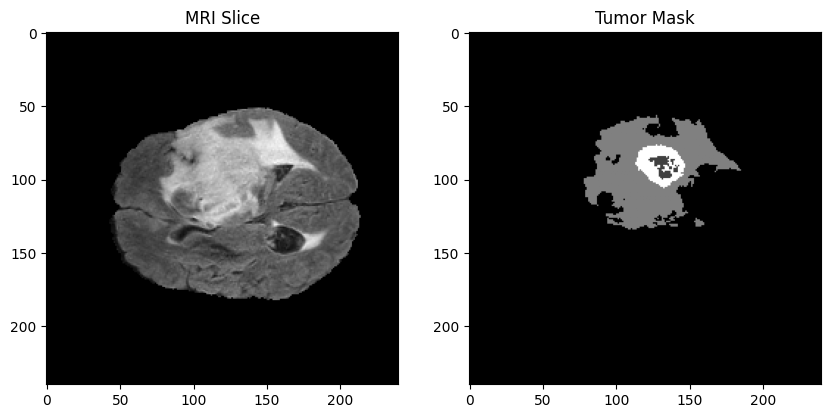

In [13]:
# Show MRI slice and tumor mask
slice_index = 75

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(flair[:,:,slice_index], cmap='gray')
plt.title("MRI Slice")

plt.subplot(1,2,2)
plt.imshow(mask[:,:,slice_index], cmap='gray')
plt.title("Tumor Mask")

plt.show()

In [14]:
# CREATE OUTPUT FOLDERS

BASE_DIR = "brain_tumor_dataset"

folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

print("Folders created.")

Folders created.


In [15]:
# Convert MASK to POLYGON ( for Yolo v8 segmentation model to work)
import cv2
import numpy as np

def mask_to_polygon(mask_slice):

    mask = (mask_slice > 0).astype(np.uint8) * 255

    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    largest = max(contours, key=cv2.contourArea)

    if cv2.contourArea(largest) < 20:   # slightly stricter
        return None

    return largest.reshape(-1, 2)

In [16]:
image_paths = []
counter = 0

for case in tqdm(cases):

    files = os.listdir(case)

    flair_path = None
    mask_path = None

    for file in files:
        if "flair" in file.lower():
            flair_path = os.path.join(case, file)
        if "seg" in file.lower():
            mask_path = os.path.join(case, file)

    if flair_path is None or mask_path is None:
        continue

    flair = nib.load(flair_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    for i in range(35, 115, 8):

        image_slice = flair[:, :, i]
        mask_slice = mask[:, :, i]

        is_tumor = np.max(mask_slice) > 0

        if not is_tumor and np.random.rand() > 0.10:
            continue

        polygon = mask_to_polygon(mask_slice)

        if polygon is None or len(polygon) < 4:
            continue

        # converting to correct OpenCV shape before approxPolyDP
        polygon = polygon.reshape(-1, 1, 2).astype(np.int32)

        polygon = cv2.approxPolyDP(
            polygon,
            epsilon=1.5,
            closed=True
        )

        if polygon is None or len(polygon) < 3:
            continue

        # reshaping after approximation
        polygon = polygon.reshape(-1, 2)

        h, w = image_slice.shape

        polygon = polygon.astype(np.float32)

        polygon[:, 0] /= w
        polygon[:, 1] /= h

        flat = polygon.flatten()

        if len(flat) < 6:
            continue

        image_slice = cv2.normalize(image_slice, None, 0, 255, cv2.NORM_MINMAX)
        image_slice = image_slice.astype(np.uint8)

        image_slice = cv2.cvtColor(image_slice, cv2.COLOR_GRAY2RGB)

        filename = f"tumor_{counter}"

        cv2.imwrite(f"{BASE_DIR}/images/train/{filename}.jpg", image_slice)

        with open(f"{BASE_DIR}/labels/train/{filename}.txt", "w") as f:
            f.write("0 " + " ".join(map(str, flat)))

        image_paths.append(filename)
        counter += 1

print("Total saved images:", counter)

100%|██████████| 369/369 [00:49<00:00,  7.50it/s]

Total saved images: 2458


In [17]:
# splitting training and validation sets

train_files, val_files = train_test_split(
    image_paths,
    test_size=0.2,
    random_state=42
)

print("Train:", len(train_files))
print("Validation:", len(val_files))

Train: 1966
Validation: 492


In [18]:
# moving the validation set files
import shutil

for file in val_files:

    shutil.copy(
        f"{BASE_DIR}/images/train/{file}.jpg",
        f"{BASE_DIR}/images/val/{file}.jpg"
    )

    shutil.copy(
        f"{BASE_DIR}/labels/train/{file}.txt",
        f"{BASE_DIR}/labels/val/{file}.txt"
    )

print("Validation files copied.")

Validation files copied.


In [19]:
# creating yolo dataset yaml file
yaml_text = f"""
path: {BASE_DIR}

train: images/train
val: images/val

names:
  0: tumor
"""

with open("dataset.yaml", "w") as f:
    f.write(yaml_text)

print("dataset.yaml created.")

dataset.yaml created.


In [20]:
# yolo v8 nano segmentation model
model = YOLO("yolov8n-seg.pt")

In [21]:
# best speed/accuracy tradeoff found after tuning and trialing multiple values
model.train(
    data="dataset.yaml",
    epochs=10,
    imgsz=192, 
    batch=8,
    workers=2,
    mosaic=0,
    fliplr=0.1,
    scale=0.1,
    degrees=0,
    patience=3,
    cache=True
)

New https://pypi.org/project/ultralytics/8.4.60 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.59  Python-3.10.20 torch-2.12.0+cpu CPU (13th Gen Intel Core i7-13700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.1, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=192, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=0, multi_scale=0.0, name=train-3, nbs=64, 

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000295E08D65F0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0410

In [22]:
# valiadate the model
metrics = model.val()
print(metrics)

Ultralytics 8.4.59  Python-3.10.20 torch-2.12.0+cpu CPU (13th Gen Intel Core i7-13700H)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 75.423.7 MB/s, size: 8.3 KB)
val: Scanning C:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\labels\val.cache... 492 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 492/492  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 5.2it/s 5.9s0.2s
                   all        492        492      0.897       0.85      0.904      0.677      0.923      0.837      0.913      0.642
Speed: 0.1ms preprocess, 7.6ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to C:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\runs\segment\val-7
ultralytics.utils.metrics.SegmentMetrics o

In [23]:
# test predictions
results = model.predict(
    source=f"{BASE_DIR}/images/val",
    save=True,
    conf=0.25
)


image 1/492 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\images\val\tumor_100.jpg: 192x192 1 tumor, 117.3ms
image 2/492 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\images\val\tumor_1004.jpg: 192x192 1 tumor, 25.6ms
image 3/492 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\images\val\tumor_1014.jpg: 192x192 1 tumor, 21.2ms
image 4/492 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\images\val\tumor_1018.jpg: 192x192 (no detections), 17.5ms
image 5/492 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\images\val\tumor_1023.jpg: 192x192 1 tumor, 16.0ms
image 6/492 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\images\val\tumor_1027.jpg: 192x192 (no detections), 16.4ms
image 7/492 c:\Us

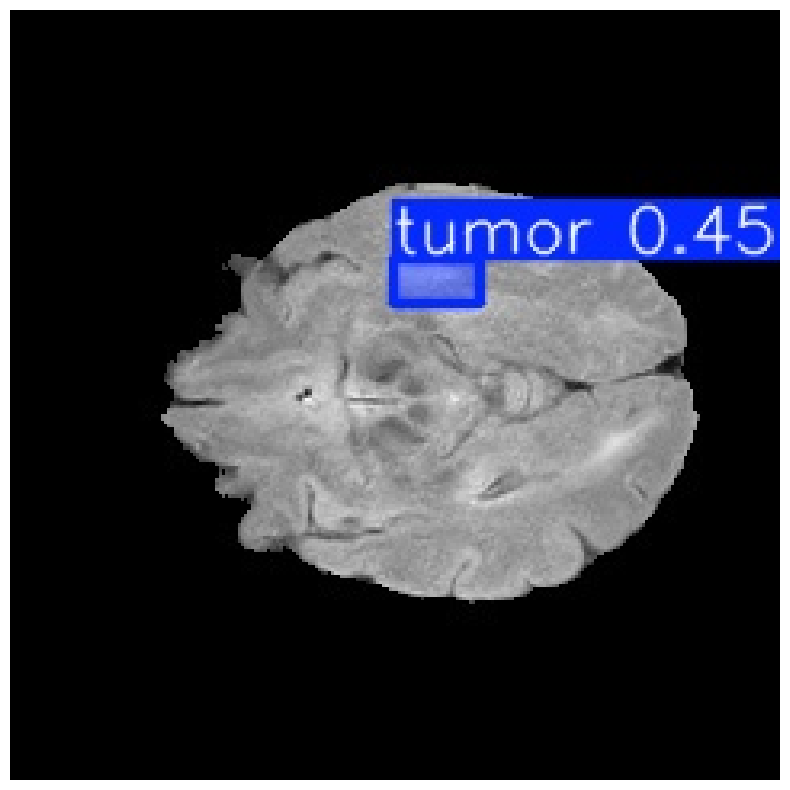

In [24]:
# displaying predictions
prediction_folder = "runs/segment/predict"

predicted_images = os.listdir(prediction_folder)

img = cv2.imread(
    os.path.join(prediction_folder, predicted_images[0])
)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [25]:
# metric scores
metrics = model.val()

print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.59  Python-3.10.20 torch-2.12.0+cpu CPU (13th Gen Intel Core i7-13700H)
val: Fast image access  (ping: 0.00.0 ms, read: 126.743.8 MB/s, size: 10.1 KB)
val: Scanning C:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\labels\val.cache... 492 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 492/492  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 5.3it/s 5.8s0.2s
                   all        492        492      0.897       0.85      0.904      0.677      0.923      0.837      0.913      0.642
Speed: 0.1ms preprocess, 7.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to C:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\runs\segment\val-8
mAP@0.5: 0.9040995459010602
mAP@0.5:0.95: 0.6767234104792494
Precision: 0.8970131982295348
Recall: 0.8497546673910834


In [27]:
# showing the true positive, false positiove or false negative counts
print(metrics.confusion_matrix.matrix)   

[[        431          62]
 [         61           0]]


# Interpretability

In [28]:
# loading the best model
from ultralytics import YOLO

model = YOLO("runs/segment/train/weights/best.pt")

Images found: 492
Loading: brain_tumor_dataset/images/val\tumor_100.jpg


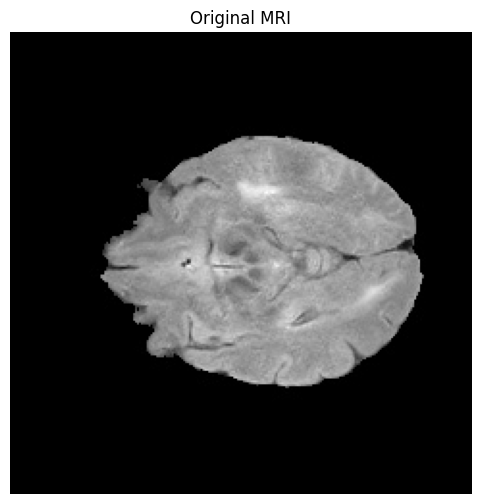

In [ ]:
# loading the image
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

val_folder = "brain_tumor_dataset/images/val"

# get image list
image_files = [
    f for f in os.listdir(val_folder)
    if f.endswith(".jpg")
]

print("Images found:", len(image_files))

# pick first image
image_name = image_files[0]

image_path = os.path.join(val_folder, image_name)

print("Loading:", image_path)

# read image
img = cv2.imread(image_path)

# safety check
if img is None:
    raise ValueError(f"Failed to load image: {image_path}")

# convert to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# normalize
img_float = img_rgb.astype(np.float32) / 255.0

# display
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Original MRI")
plt.axis("off")
plt.show()

In [30]:
# Yolo prediction
results = model.predict(
    image_path,
    conf=0.25
)

result = results[0]

print(result)


image 1/1 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\images\val\tumor_100.jpg: 192x192 1 tumor, 19.9ms
Speed: 0.7ms preprocess, 19.9ms inference, 1.4ms postprocess per image at shape (1, 3, 192, 192)
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'tumor'}
obb: None
orig_img: array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

     

In [31]:
print(result.speed)

{'preprocess': 0.6599000189453363, 'inference': 19.93050007149577, 'postprocess': 1.430200063623488}


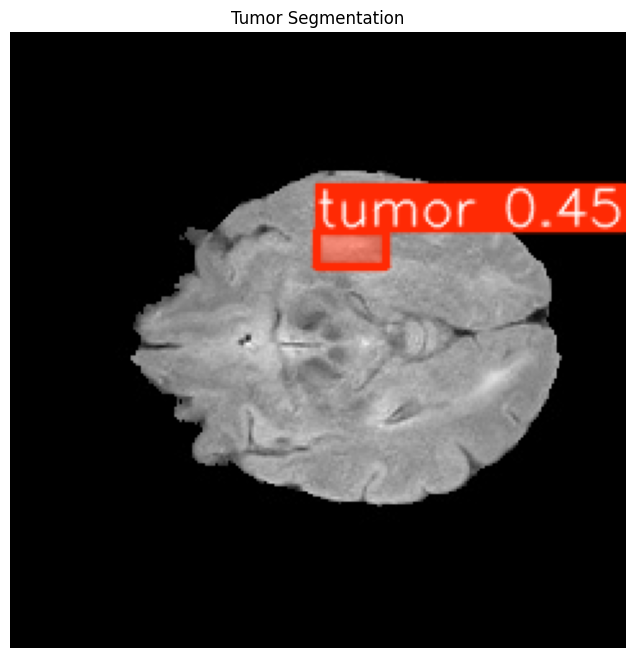

In [32]:
# segmented visualisation
seg_res_img = result.plot()

annotseg_res_imgated = cv2.cvtColor(seg_res_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(seg_res_img)
plt.title("Tumor Segmentation")
plt.axis("off")
plt.show()

# Clinical confidence score

In [33]:
boxes = result.boxes

if boxes is None or len(boxes) == 0:
    print("No tumor detected.")
    print("Model confidence insufficient for reliable localization.")
else:
    for i, box in enumerate(boxes):
        
        confidence = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0]

        width = x2 - x1
        height = y2 - y1

        area = width * height

        uncertainty = 1 - confidence

        print(f"Tumor Detection #{i+1}")
        print("-" * 50)

        print(f"Confidence Score: {confidence:.3f}")
        print(f"Prediction Uncertainty: {uncertainty:.3f}")

        if confidence > 0.90:
            print("High-confidence tumor localization.")
        elif confidence > 0.75:
            print("Moderate-confidence tumor localization.")
        else:
            print("Low-confidence prediction. Clinical review recommended.")

        print(f"Estimated Tumor Area: {area:.1f}")

        if area > 10000:
            print("Tumor region appears relatively large.")
        else:
            print("Tumor region appears relatively small.")

Tumor Detection #1
--------------------------------------------------
Confidence Score: 0.447
Prediction Uncertainty: 0.553
Low-confidence prediction. Clinical review recommended.
Estimated Tumor Area: 359.9
Tumor region appears relatively small.


# morphology analysis

In [34]:
if result.masks is not None:

    masks = result.masks.data.cpu().numpy()

    for i, mask in enumerate(masks):

        binary_mask = (mask > 0.5).astype(np.uint8)

        area = np.sum(binary_mask)

        contours, _ = cv2.findContours(
            binary_mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        if len(contours) == 0:
            continue

        contour = max(contours, key=cv2.contourArea)

        perimeter = cv2.arcLength(contour, True)

        compactness = (4 * np.pi * area) / (perimeter ** 2 + 1e-6)

        print(f"Tumor Morphology #{i+1}")
        print("-" * 50)

        print(f"Tumor Area: {area}")

        print(f"Tumor Perimeter: {perimeter:.2f}")

        print(f"Compactness: {compactness:.3f}")

        if compactness < 0.5:
            print("Tumor shape appears irregular.")

        else:
            print("Tumor shape appears relatively compact.")

        print()

Tumor Morphology #1
--------------------------------------------------
Tumor Area: 288
Tumor Perimeter: 68.00
Compactness: 0.783
Tumor shape appears relatively compact.



# Grad CAM++

In [35]:
target_layers = [
    model.model.model[9]
]


In [36]:
input_tensor = torch.tensor(
    img_float.transpose(2,0,1)
).unsqueeze(0).float()

cam = GradCAMPlusPlus(
    model=model.model,
    target_layers=target_layers
)

In [38]:
input_tensor.requires_grad_(True)

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]], requires_grad=True)

Using conv layer: backbone.2.cv2.conv - Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1))
Using conv layer: backbone.2.m.0.cv2.conv - Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Using conv layer: backbone.4.cv2.conv - Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
Using conv layer: backbone.4.m.0.cv2.conv - Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Using conv layer: backbone.4.m.1.cv2.conv - Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Using conv layer: backbone.6.cv2.conv - Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1))
Using conv layer: backbone.6.m.0.cv2.conv - Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Using conv layer: backbone.6.m.1.cv2.conv - Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Using conv layer: backbone.8.cv2.conv - Conv2d(384, 256, kernel_size=(1, 1), stride=(1, 1))
Using conv layer: backbone.8.m.0.cv2.conv - Conv2d(128, 128, kernel_size=(3, 3), stri

c:\Users\conno\anaconda3\envs\brats_final\lib\site-packages\torch\nn\modules\module.py:1869: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


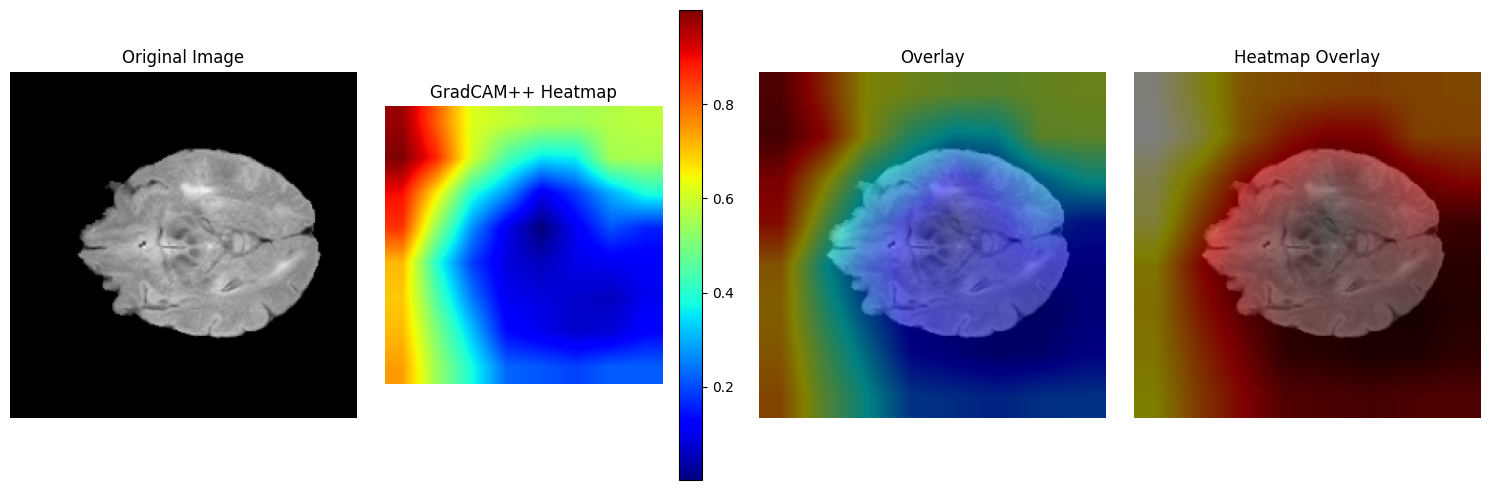

Saved as 'gradcam_yolo_working.jpg'


In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

class YOLOSegmentationCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
        
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def __call__(self, x):
        # forward pass
        output = self.model(x)
        
        if isinstance(output, (tuple, list)):
            total_loss = 0
            for i, out in enumerate(output):
                if isinstance(out, torch.Tensor) and out.numel() > 0:
                    # Sum of absolute values as pseudo-loss
                    total_loss = total_loss + out.abs().sum() / (i + 1)
        else:
            total_loss = output.abs().sum()
        
        # backward pass
        self.model.zero_grad()
        total_loss.backward(retain_graph=True)
        
        # computing CAM
        if self.gradients is not None and self.activations is not None:
            weights = self.gradients.mean(dim=(2, 3), keepdim=True)
            cam = (weights * self.activations).sum(dim=1, keepdim=True)
            cam = torch.relu(cam)
            cam = cam.squeeze().detach().cpu().numpy()
            
            # handle different dimensions
            if len(cam.shape) == 3:
                cam = cam[0] if cam.shape[0] == 1 else cam.mean(axis=0)
            elif len(cam.shape) == 2:
                pass
            else:
                cam = cam.squeeze()
            
            # normalize
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
            return cam
        else:
            raise ValueError("No gradients or activations captured")

# creating backbone
class YOLOBackbone(torch.nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.backbone = torch.nn.Sequential(*list(original_model.children())[:10])
        
    def forward(self, x):
        return self.backbone(x)

backbone_model = YOLOBackbone(model.model.model)

# finding a good conv layer
target_conv = None
for name, module in backbone_model.named_modules():
    if isinstance(module, torch.nn.Conv2d) and 'cv2' in name:  # Use last conv of each block
        target_conv = module
        print(f"Using conv layer: {name} - {module}")

if target_conv is None:
    # fallback to last conv if none
    for module in reversed(list(backbone_model.modules())):
        if isinstance(module, torch.nn.Conv2d):
            target_conv = module
            print(f"Using conv layer: {target_conv}")
            break

# create the CAM generator
cam_generator = YOLOSegmentationCAM(backbone_model, target_conv)

# generate CAM
with torch.enable_grad():
    input_tensor.requires_grad_(True)
    grayscale_cam = cam_generator(input_tensor)
    
print(f"CAM shape: {grayscale_cam.shape}")
print(f"CAM range: {grayscale_cam.min():.3f} - {grayscale_cam.max():.3f}")

# Visualize
original_img = cv2.imread(image_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
original_img = cv2.resize(original_img, (224, 224))
original_img_normalized = original_img / 255.0

# resize CAM to match the image
grayscale_cam_resized = cv2.resize(grayscale_cam, (224, 224))

# create  the visualization
visualization = show_cam_on_image(original_img_normalized, grayscale_cam_resized, use_rgb=True)

# plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(original_img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
im = plt.imshow(grayscale_cam_resized, cmap='jet')
plt.title('GradCAM++ Heatmap')
plt.axis('off')
plt.colorbar(im)

plt.subplot(1, 4, 3)
plt.imshow(visualization)
plt.title('Overlay')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(original_img)
plt.imshow(grayscale_cam_resized, cmap='hot', alpha=0.5)
plt.title('Heatmap Overlay')
plt.axis('off')

plt.tight_layout()
plt.show()

# save the result
cv2.imwrite('gradcam_yolo_working.jpg', cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR))
print("Saved as 'gradcam_yolo_working.jpg'")

In [40]:
print(torch.__version__)
print(ultralytics.__version__)

2.12.0+cpu
8.4.59


In [41]:
print(torch.__version__)
print(torch.is_inference_mode_enabled())

2.12.0+cpu
False
